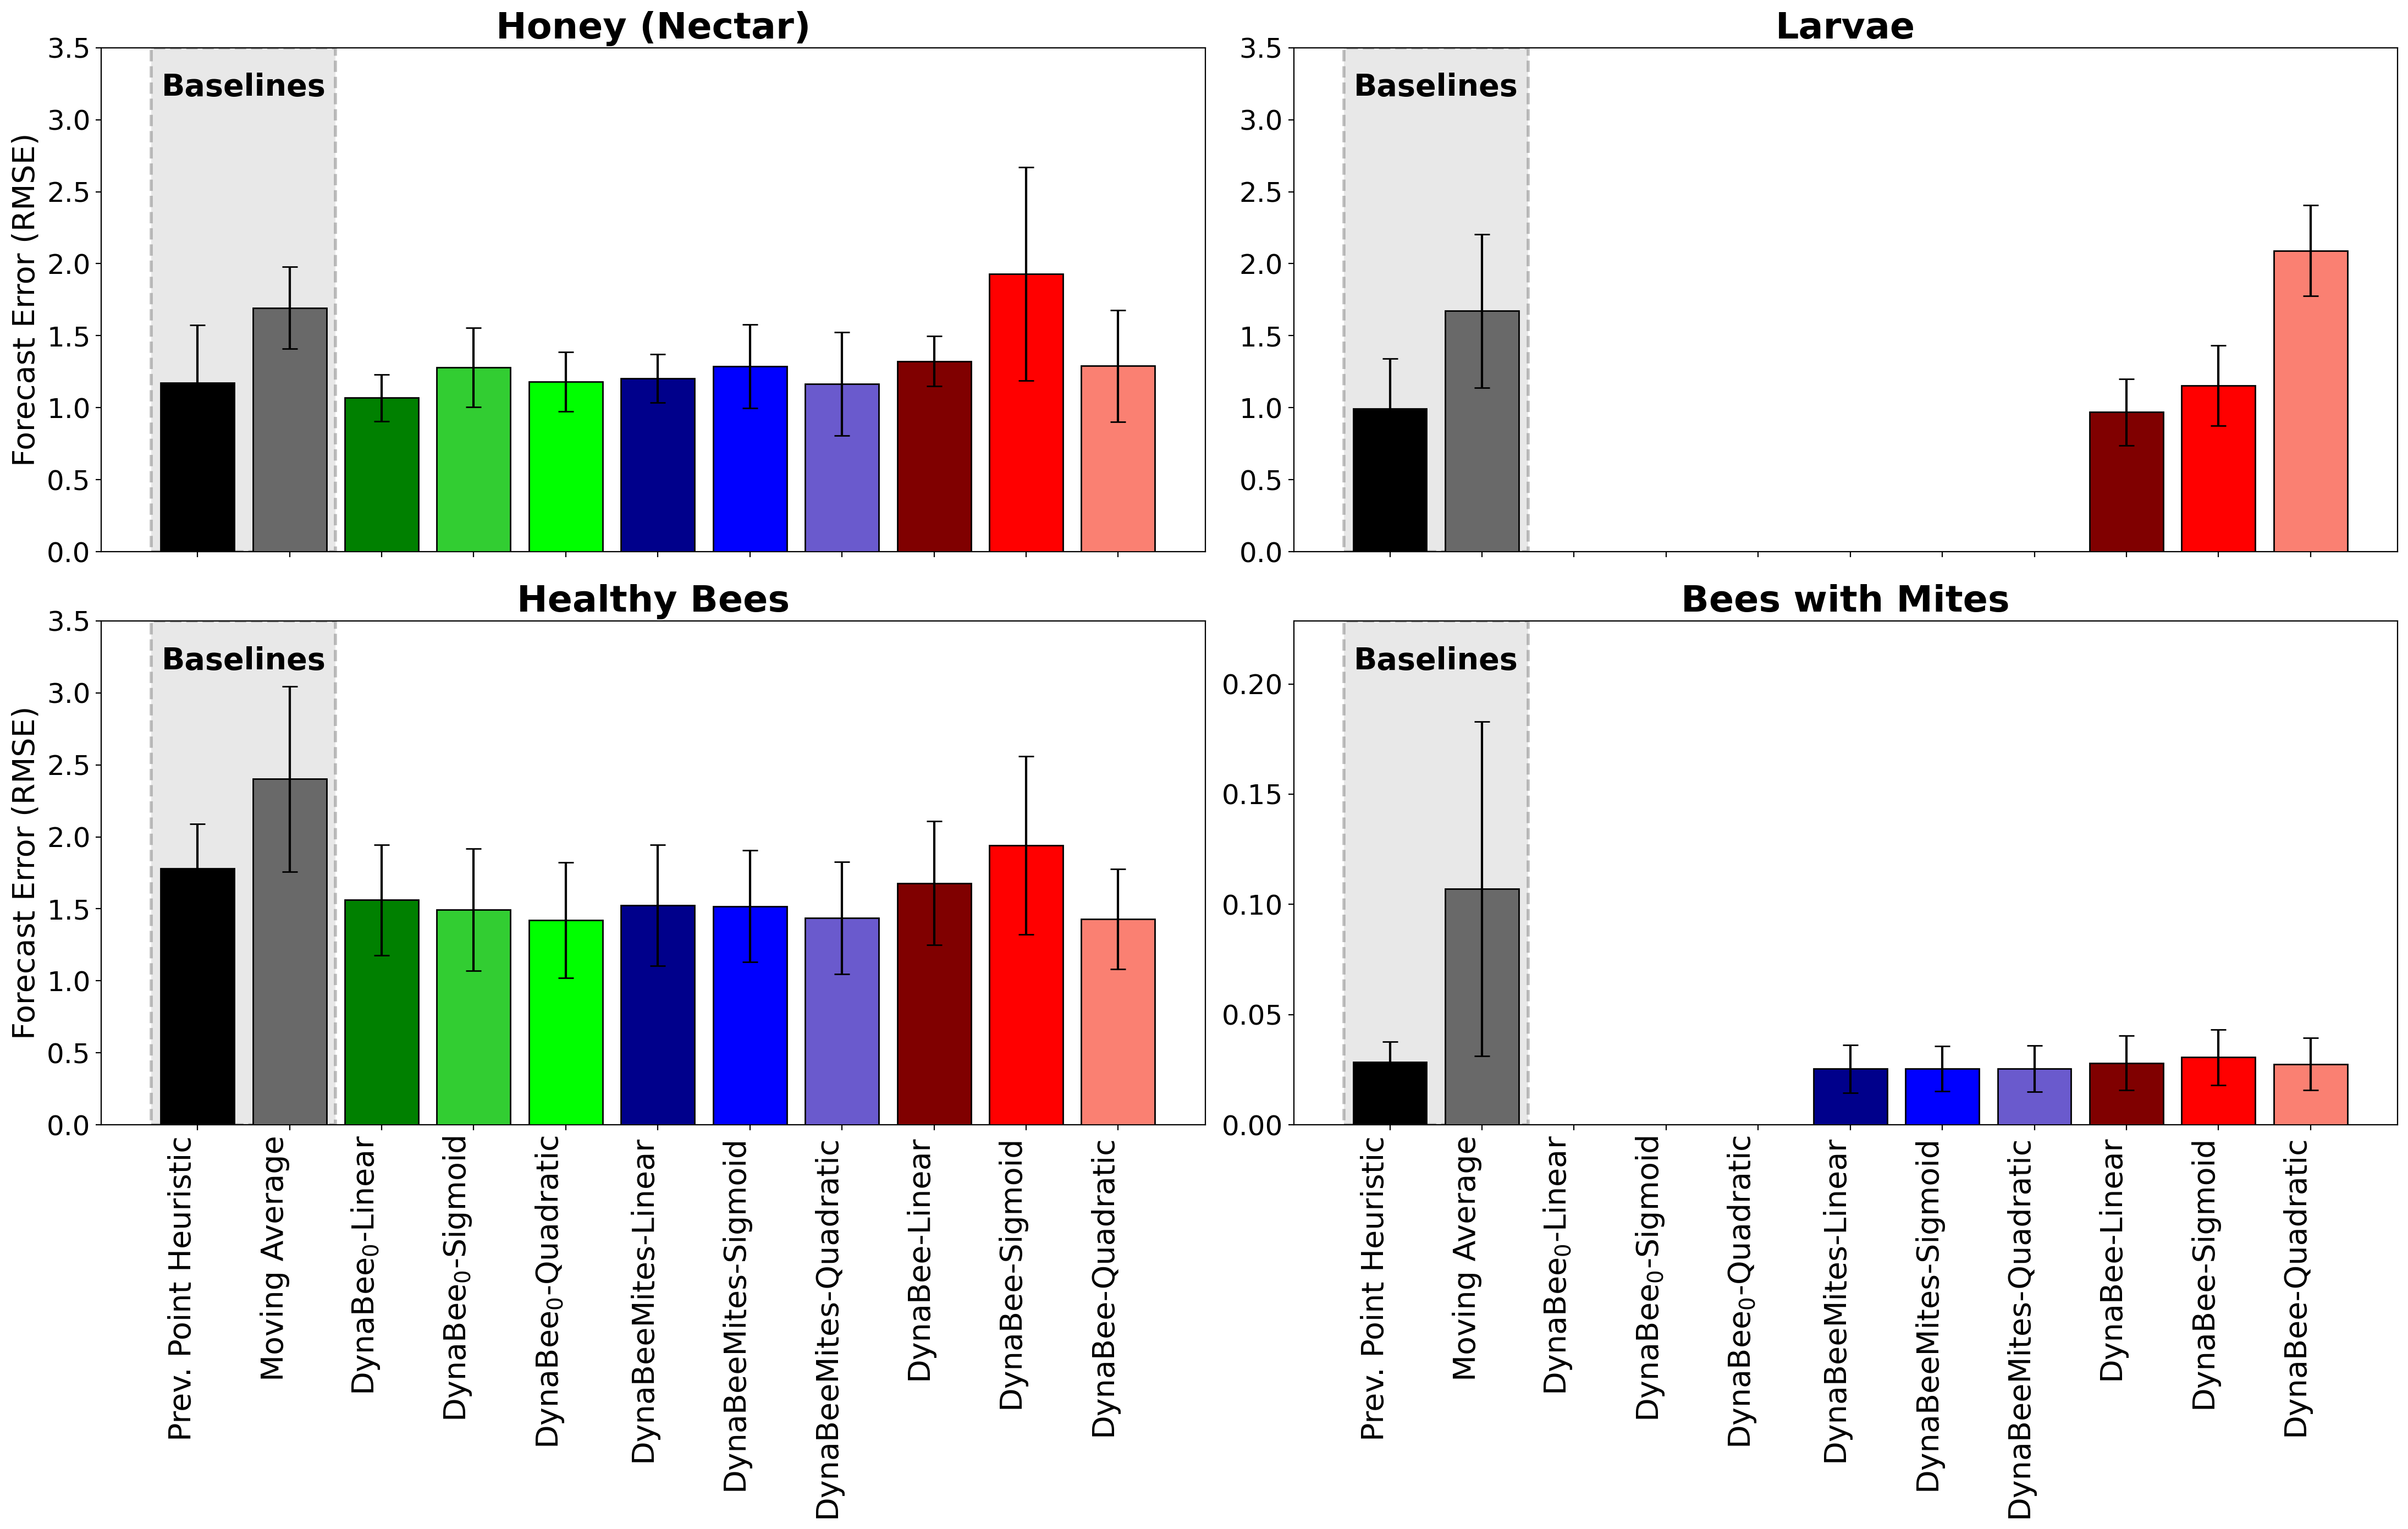

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# =========================================================
# DATA
# =========================================================

data_all = [
    {
        "Honey (Nectar)": {
            "mean": [1.17125, 1.69395, 1.06805, 1.279683333, 1.180233333,
                     1.202116667, 1.28655, 1.16445, 1.323483333,
                     1.928383333, 1.290133333],
            "std": [0.4041798053, 0.2859518893, 0.1638892644, 0.2763026052,
                    0.2075703511, 0.167915841, 0.2895338167, 0.3584461563,
                    0.1746074158, 0.7408113239, 0.3883309036],
            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Healthy Bees": {
            "mean": [1.780566667, 2.4027, 1.561166667, 1.494166667,
                     1.420983333, 1.525733333, 1.518233333, 1.437366667,
                     1.679216667, 1.940083333, 1.427966667],
            "std": [0.3100933838, 0.6434812227, 0.3849367151,
                    0.4239356634, 0.4020209866, 0.419709741,
                    0.3870550693, 0.3906107508, 0.4297877309,
                    0.6193030257, 0.3479209201],
            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Larvae": {
            "mean": [0.9926666667, 1.671333333, 0, 0, 0, 0, 0, 0,
                     0.9686833333, 1.152833333, 2.089883333],
            "std": [0.3497867846, 0.53165749, 0, 0, 0, 0, 0, 0,
                    0.2323264636, 0.2796309401, 0.3153059874],
            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Bees with Mites": {
            "mean": [0.02843333333, 0.1070833333, 0, 0, 0,
                     0.02538333333, 0.02548333333, 0.02558333333,
                     0.0281, 0.03063333333, 0.02758333333],
            "std": [0.009385449732, 0.07583166665, 0, 0, 0,
                    0.01086929927, 0.01028035343, 0.01048435342,
                    0.01230528342, 0.01252496174, 0.01179600215],
            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        }
    }
]

# =========================================================
# COLORS
# =========================================================

color_map = {
    r'Prev. Point Heuristic': 'black',
    r'Moving Average': 'dimgray',
    r'DynaBee$_0$-Linear': 'green',
    r'DynaBee$_0$-Sigmoid': 'limegreen',
    r'DynaBee$_0$-Quadratic': 'lime',
    r'DynaBeeMites-Linear': 'darkblue',
    r'DynaBeeMites-Sigmoid': 'blue',
    r'DynaBeeMites-Quadratic': 'slateblue',
    r'DynaBee-Linear': 'maroon',
    r'DynaBee-Sigmoid': 'red',
    r'DynaBee-Quadratic': 'salmon',
}

# =========================================================
# PLOTTING
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(22, 14), dpi=200)

col_titles = ['Honey (Nectar)',  'Larvae', 'Healthy Bees', 'Bees with Mites']

for row_idx, dataset in enumerate(data_all):

    for col_idx, variable in enumerate(col_titles):

        row = col_idx // 2
        col = col_idx % 2
        ax = axes[row, col]

        ax.set_title(variable, fontsize=24, fontweight='bold')

        means = dataset[variable]["mean"]
        stds = dataset[variable]["std"]
        labels = dataset[variable]["labels"]

        x = np.arange(len(means))
        colors = [color_map[label] for label in labels]

        # -------------------------------------------------
        # Y-limit
        # -------------------------------------------------

        if variable != "Bees with Mites":
            ymax = 3.5
            ax.set_ylim([0, ymax])
        else:
            ymax = max(np.array(means) + np.array(stds)) * 1.25
            ax.set_ylim([0, ymax])

        # -------------------------------------------------
        # Shadow box for first two bars
        # -------------------------------------------------

        ax.add_patch(
            Rectangle(
                (-0.5, 0),
                2.0,
                ymax,
                facecolor='lightgray',
                edgecolor='gray',
                linestyle='--',
                linewidth=2,
                alpha=0.50,
                zorder=0
            )
        )

        ax.text(
            0.5,
            ymax * 0.95,
            "Baselines",
            ha='center',
            va='top',
            fontsize=20,
            fontweight='bold'
        )

        # -------------------------------------------------
        # Bar plot
        # -------------------------------------------------

        ax.bar(
            x,
            means,
            yerr=stds,
            capsize=5,
            color=colors,
            edgecolor='black',
            zorder=3
        )

        # -------------------------------------------------
        # Y label only on first column
        # -------------------------------------------------

        if col == 0:
            ax.set_ylabel(
                'Forecast Error (RMSE)',
                fontsize=20
            )

        # -------------------------------------------------
        # X ticks only on second row
        # -------------------------------------------------

        if row == 1:
            ax.set_xticks(x)
            ax.set_xticklabels(
                labels,
                rotation=90,
                ha='right',
                fontsize=20
            )
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])

        # -------------------------------------------------
        # Grid and ticks
        # -------------------------------------------------

        #ax.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=1)
        ax.tick_params(axis='y', labelsize=18)

plt.tight_layout()
plt.show()

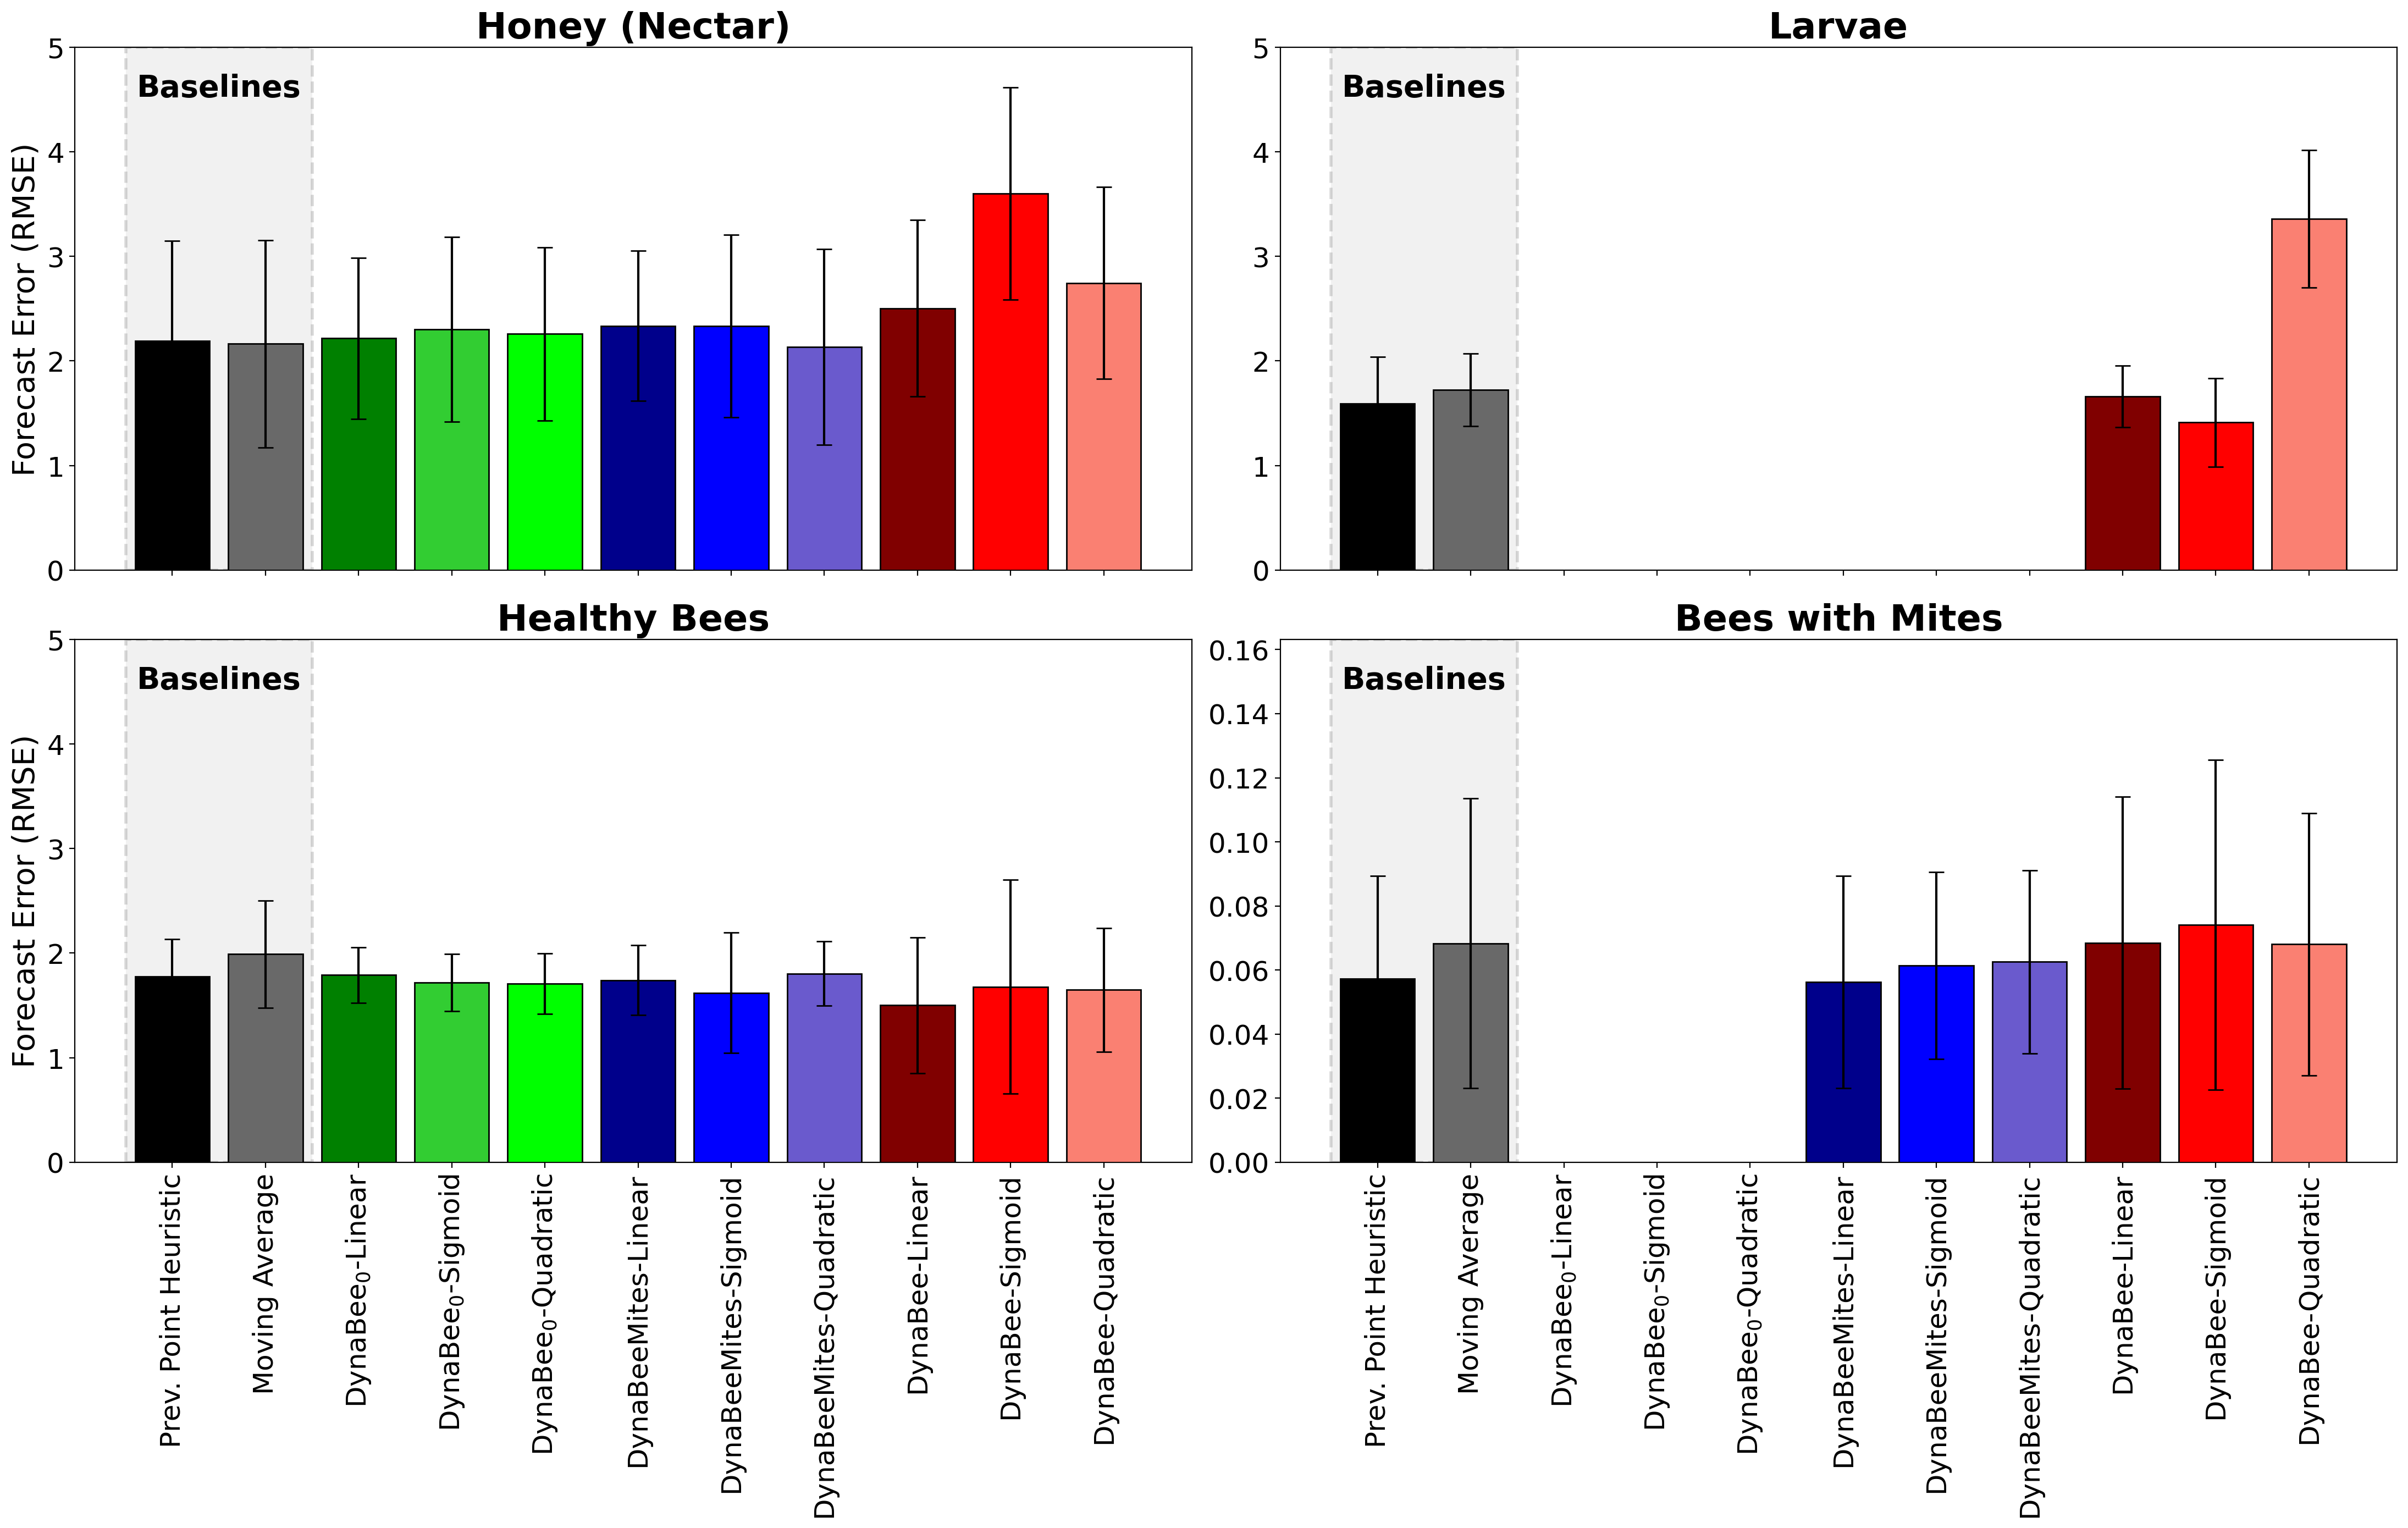

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# DATA
# =========================================================

data_all = [

    # =====================================================
    # DATA 1
    # =====================================================

    {
        "Honey (Nectar)": {
            "mean": [2.193345455, 2.162727273, 2.2156, 2.303018182, 2.258036364, 2.335963636,
                     2.333254545, 2.133654545, 2.504281818, 3.598409091, 2.743563636],

            "std": [0.9555518483, 0.9895334033, 0.7705710675, 0.8840994806, 0.82825524, 0.7191656044, 
                    0.8711105192, 0.9333831607, 0.8415909384, 1.014842098, 0.9171125245],

            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Healthy Bees": {
            "mean": [1.773663636, 1.990536364, 1.790045455, 1.719027273, 1.708681818, 
                     1.741209091, 1.620190909, 1.803363636, 1.500263636, 1.678790909, 1.647836364],

            "std": [0.358317441, 0.5128368576, 0.2650512719, 0.2717360782, 0.2885164287, 
                    0.3352427701, 0.5762925341, 0.3070295434, 0.6489269686,1.021215036, 0.5902172689],

            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Bees with Mites": {
            "mean": [0.05724545455, 0.06834545455, 0, 0, 0, 
                     0.05624545455, 0.06145454545, 0.06254545455, 0.06851818182, 0.07409090909, 0.06804545455],

            "std": [0.03212576423, 0.04519863634, 0, 0, 0, 0.03318036659, 
                    0.02916790577, 0.02855606288, 0.04561407279, 0.05146135355, 0.04095117492],

            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        },

        "Larvae": {
            "mean": [1.593781818, 1.723781818,  0, 0, 0, 0, 0, 0, 1.659563636, 1.411927273, 3.356636364],

            "std": [0.4459432695, 0.3482207915, 0, 0, 0, 0, 0, 0, 0.2955658481, 0.4226743808, 0.6577924266],

            "labels": [
                r'Prev. Point Heuristic',
                r'Moving Average',
                r'DynaBee$_0$-Linear',
                r'DynaBee$_0$-Sigmoid',
                r'DynaBee$_0$-Quadratic',
                r'DynaBeeMites-Linear',
                r'DynaBeeMites-Sigmoid',
                r'DynaBeeMites-Quadratic',
                r'DynaBee-Linear',
                r'DynaBee-Sigmoid',
                r'DynaBee-Quadratic',
            ]
        }
    }
]

# =========================================================
# COLORS
# =========================================================

color_map = {
    r'Prev. Point Heuristic': 'black',
    r'Moving Average': 'dimgray',
    r'DynaBee$_0$-Linear': 'green',
    r'DynaBee$_0$-Sigmoid': 'limegreen',
    r'DynaBee$_0$-Quadratic': 'lime',
    r'DynaBeeMites-Linear': 'darkblue',
    r'DynaBeeMites-Sigmoid': 'blue',
    r'DynaBeeMites-Quadratic': 'slateblue',
    r'DynaBee-Linear': 'maroon',
    r'DynaBee-Sigmoid': 'red',
    r'DynaBee-Quadratic': 'salmon',
}

# =========================================================
# PLOTTING
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(22, 14), dpi=200)

col_titles = [
    'Honey (Nectar)',
    'Larvae',
    'Healthy Bees',
    'Bees with Mites'
]

for row_idx, dataset in enumerate(data_all):

    for col_idx, variable in enumerate(col_titles):

        row = col_idx // 2
        col = col_idx % 2

        ax = axes[row, col]

        means = dataset[variable]["mean"]
        stds = dataset[variable]["std"]
        labels = dataset[variable]["labels"]

        x = np.arange(len(means))
        colors = [color_map[label] for label in labels]

        # =================================================
        # Axis limits
        # =================================================

        if variable != "Bees with Mites":
            ymax = 5.0
            ax.set_ylim(0, ymax)
        else:
            ymax = max(np.array(means) + np.array(stds)) * 1.3
            ax.set_ylim(0, ymax)

        # =================================================
        # Baseline shadow region
        # =================================================

        ax.add_patch(
            Rectangle(
                (-0.5, 0),      # start before first bar
                2.0,            # first two bars
                ymax,
                facecolor='lightgray',
                edgecolor='gray',
                linestyle='--',
                linewidth=2,
                alpha=0.30,
                zorder=0
            )
        )

        ax.text(
            0.5,
            ymax * 0.95,
            "Baselines",
            ha='center',
            va='top',
            fontsize=20,
            fontweight='bold'
        )

        # =================================================
        # Bars
        # =================================================

        bars = ax.bar(
            x,
            means,
            yerr=stds,
            capsize=5,
            color=colors,
            edgecolor='black',
            linewidth=1,
            zorder=3
        )

        # =================================================
        # Titles
        # =================================================

        ax.set_title(
            variable,
            fontsize=24,
            fontweight='bold'
        )

        
        # =================================================
        # Y labels only first column
        # =================================================

        if col == 0:
            ax.set_ylabel(
                'Forecast Error (RMSE)',
                fontsize=20
            )

        # =================================================
        # X labels only bottom row
        # =================================================

        if row == 1:

            ax.set_xticks(x)

            ax.set_xticklabels(
                labels,
                rotation=90,
                ha='center',
                fontsize=18
            )

        else:

            ax.set_xticks(x)
            ax.set_xticklabels([])

        # =================================================
        # Grid
        # =================================================

        ax.tick_params(
            axis='y',
            labelsize=18
        )

# =========================================================
# Layout
# =========================================================

plt.tight_layout()
plt.show()

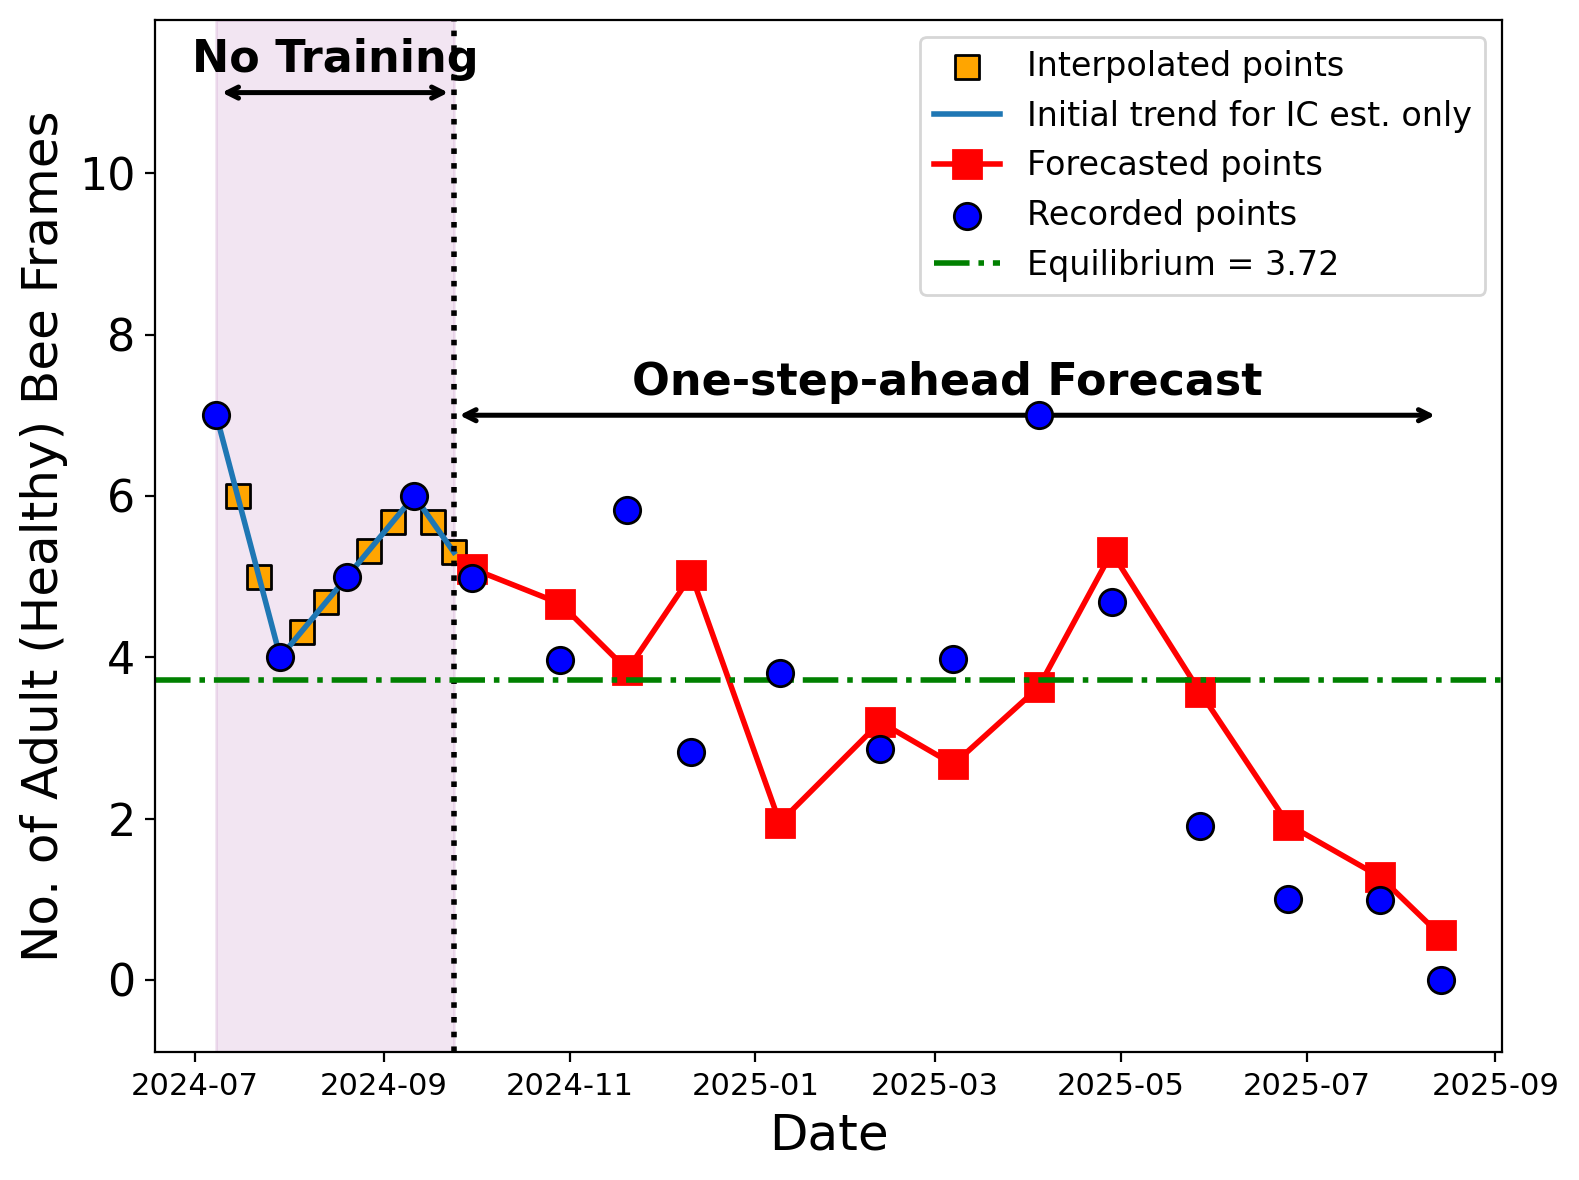

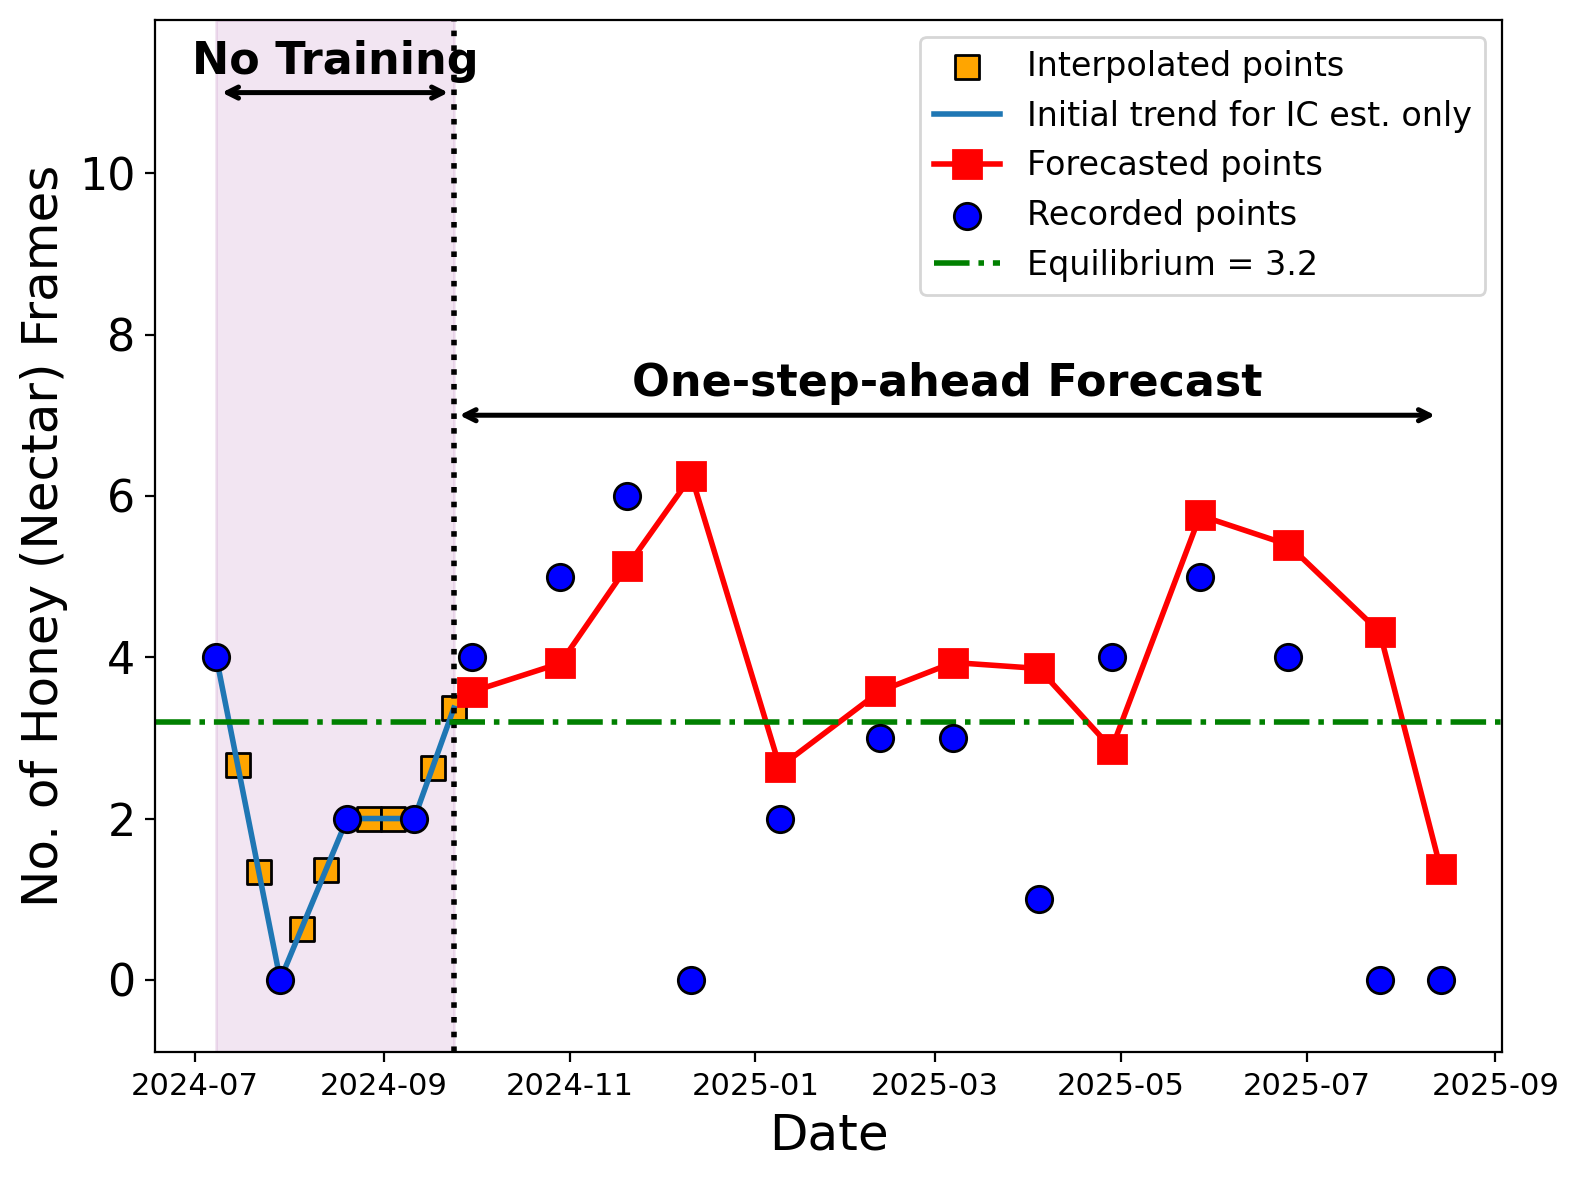

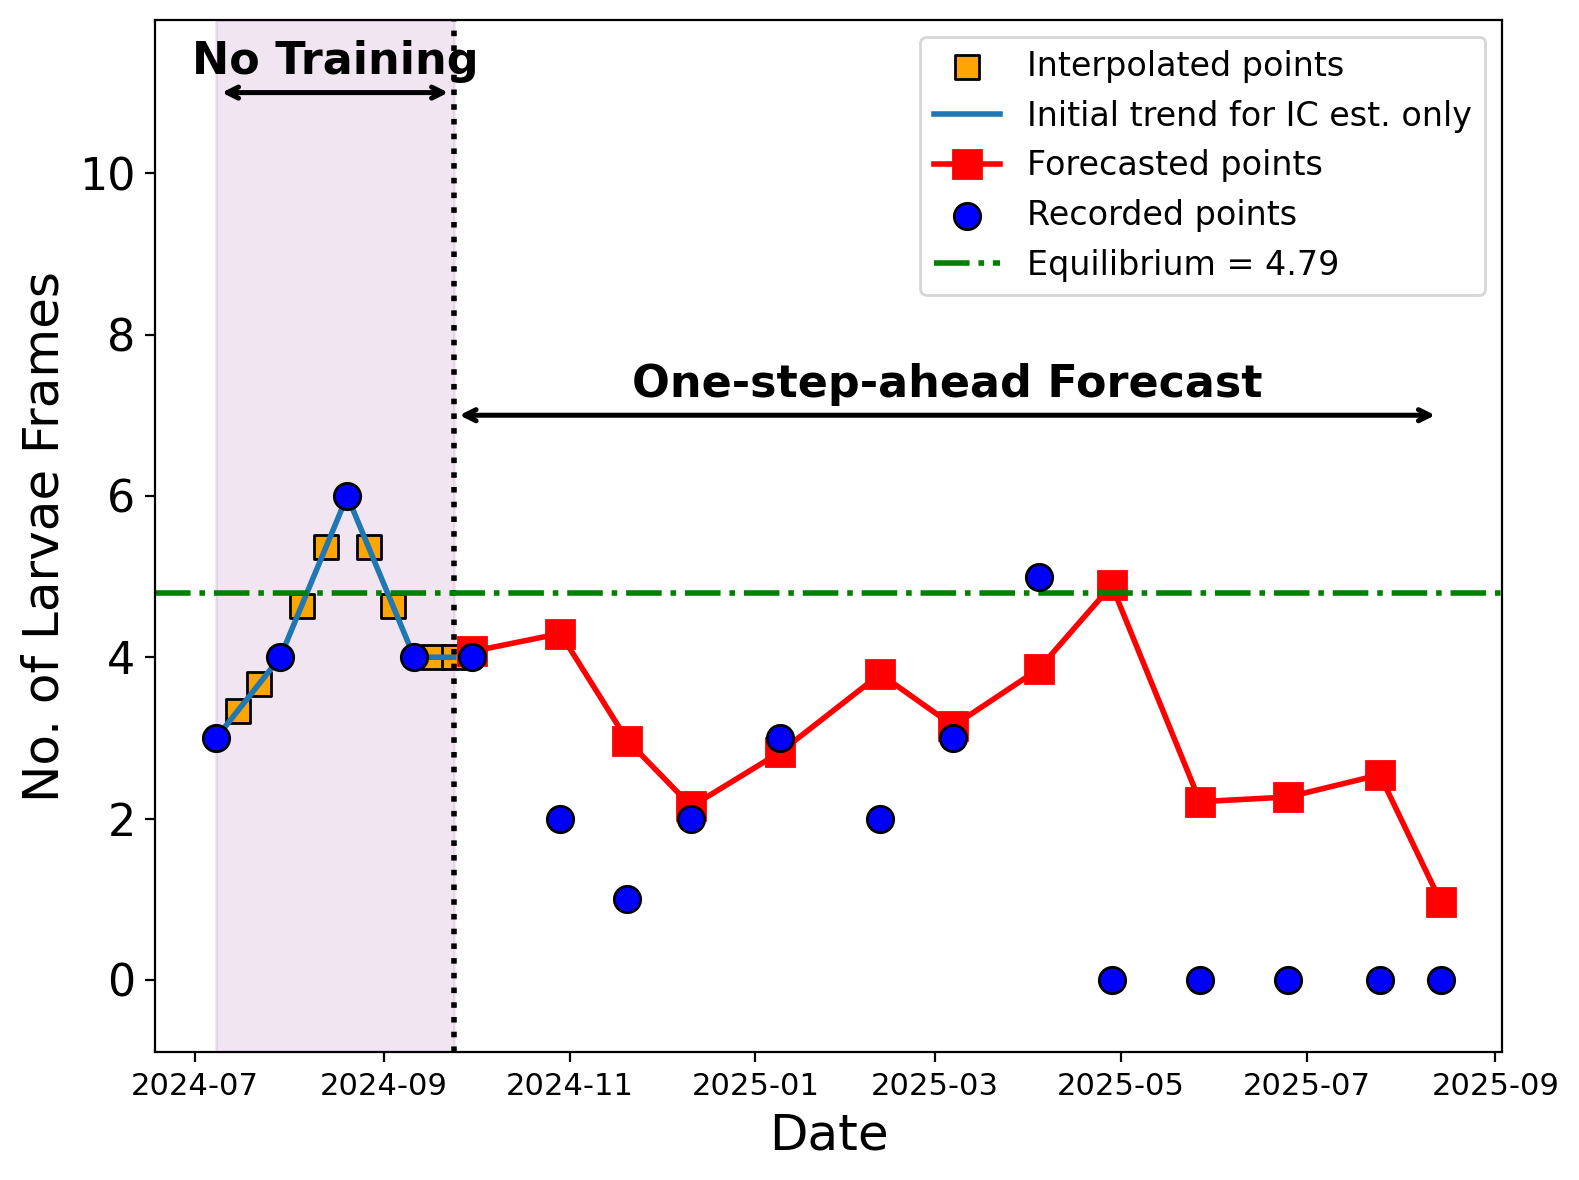

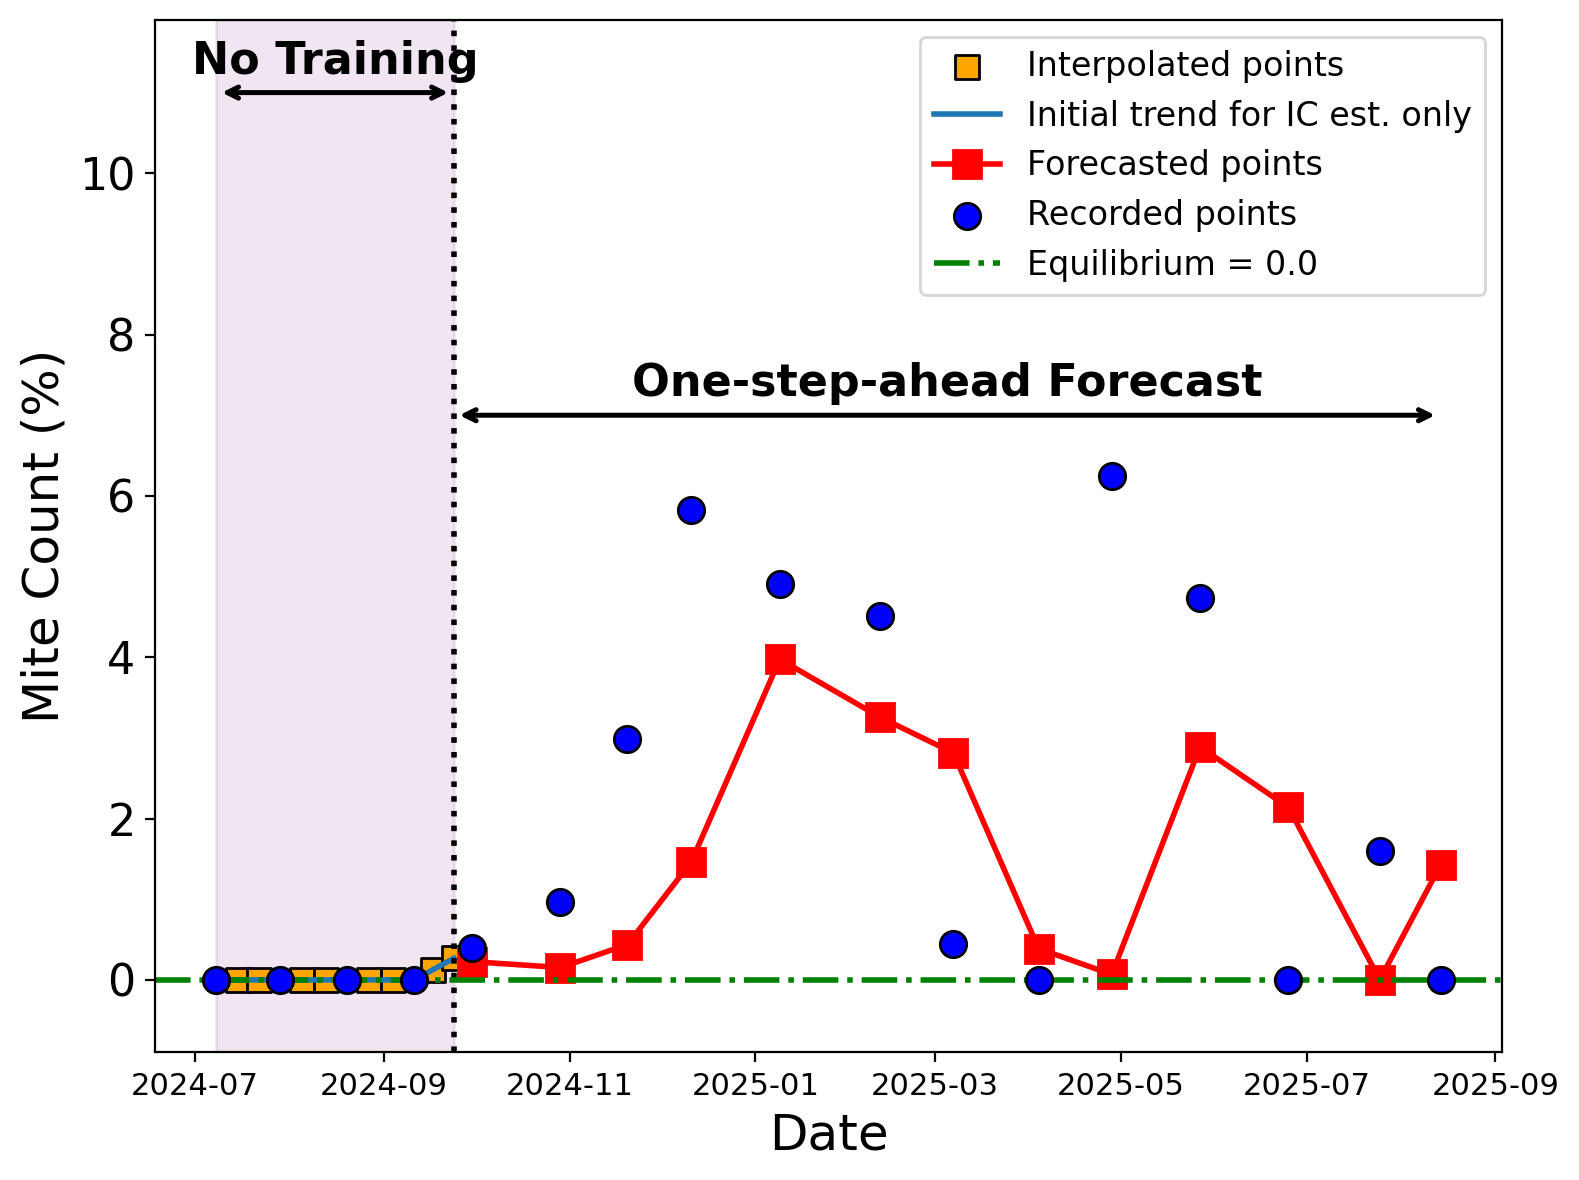

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# =========================
# Load data
# =========================
file_path = r"c:\Bee Temp Data\24-M9-fig-model-6.csv"   # update path if needed
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# =========================
# Settings
# =========================
training_n = 12

nectar_eq = np.round(3.201272173533209,2)
bee_mite_eq = np.round(2.99861243028284e-08,2)
bee_eq = np.round(3.72250046639967,2)
larvae_eq = np.round(4.787334820762886,2)

original = df[df["Type"] == "Original"]
interp = df[df["Type"] == "Interpolated"]

# =========================
# Helper function
# =========================
def plot_variable_with_forecast(
    df,
    original,
    interp,
    y_col,
    forecast_col,
    eq_value,
    ylabel,
    upper_ylim,
    y1,
    y2,
):
    fig, ax = plt.subplots(figsize=(8, 6), dpi = 200)

    start_date = df["Date"].iloc[0]
    train_end_date = df["Date"].iloc[training_n - 1]
    forecast_end_date = df["Date"].iloc[-1]

    y_min = min(df[y_col].min(), df[forecast_col].min(), eq_value)
    y_max = max(df[y_col].max(), df[forecast_col].max(), eq_value)
    y_range = y_max - y_min if y_max > y_min else 1

    # Give space for arrows/text
    ax.set_ylim(-0.9, upper_ylim)

    arrow_y1 = y1
    arrow_y2 = y2

    # -------------------------
    # Grey background for training input region
    # -------------------------
    ax.axvspan(
        start_date,
        train_end_date,
        color="purple",
        alpha=0.1,
        #label="Training input region"
    )

    # -------------------------
    # Plot ALL observed points
    # -------------------------
   

    ax.scatter(
        interp["Date"],
        interp[y_col],
        color='orange',
        label="Interpolated points",
        marker="s",
        edgecolor="black",
        s=80
    )

    # -------------------------
    # Line plot for first 12 training points
    # -------------------------
    train_df = df.iloc[:training_n]

    ax.plot(
        train_df["Date"],
        train_df[y_col],
        linewidth=2,
        label="Initial trend for IC est. only"
    )

    # -------------------------
    # Forecasted values
    # -------------------------
    forecast_df = df[df[forecast_col].notna()]

    ax.plot(
        forecast_df["Date"],
        forecast_df[forecast_col],
        #linestyle="--",
        linewidth=2,
        marker="s",
        #edgecolor="black",
        markersize=10,
        label="Forecasted points",
        color = 'red',
        zorder = 2,
    )
    
    ax.scatter(
        original["Date"],
        original[y_col],
        color='blue',
        label="Recorded points",
        marker="o",
        edgecolor="black",
        s=90,
        zorder = 5,
    )

    # -------------------------
    # Vertical line at 12th point
    # -------------------------
    ax.axvline(
        x=train_end_date,
        linestyle=":",
        linewidth=2,
        color='black'
        #label="End of initial training samples"
    )

    # -------------------------
    # Horizontal equilibrium line
    # -------------------------
    ax.axhline(
        y=eq_value,
        linestyle="-.",
        linewidth=2,
        label=f"Equilibrium = {eq_value}",
        color='green'
    )

    # -------------------------
    # Double arrow: Training Input
    # -------------------------
    ax.annotate(
        "",
        xy=(start_date, arrow_y1),
        xytext=(train_end_date, arrow_y1),
        arrowprops=dict(arrowstyle="<->", linewidth=1.8)
    )

    ax.text(
        start_date + (train_end_date - start_date) / 2,
        arrow_y1 + 0.02 * y_range,
        "No Training",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    # -------------------------
    # Double arrow: One-step-ahead Forecast
    # -------------------------
    ax.annotate(
        "",
        xy=(train_end_date, arrow_y2),
        xytext=(forecast_end_date, arrow_y2),
        arrowprops=dict(arrowstyle="<->", linewidth=1.8)
    )

    ax.text(
        train_end_date + (forecast_end_date - train_end_date) / 2,
        arrow_y2 + 0.02 * y_range,
        "One-step-ahead Forecast",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_xlabel("Date", fontsize = 18)
    ax.set_ylabel(ylabel, fontsize = 18)

    #ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=0, fontsize = 11)
    plt.yticks(fontsize = 16)

    ax.legend( fontsize=12)
    plt.tight_layout()

    plt.show()


# =========================
# Plot 1: Healthy bees
# =========================
plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Frame Healthy Bees",
    forecast_col="Bee Forecast",
    eq_value=bee_eq,
    ylabel="No. of Adult (Healthy) Bee Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

# =========================
# Plot 2: Nectar
# =========================
plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Nectar",
    forecast_col="Nectar Forecast",
    eq_value=nectar_eq,
    ylabel="No. of Honey (Nectar) Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Frames Brood",
    forecast_col="Larvae Forecast",
    eq_value=larvae_eq,
    ylabel="No. of Larvae Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="# Mites",
    forecast_col="Mite Forecast Per",
    eq_value=bee_mite_eq,
    ylabel="Mite Count (%)",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

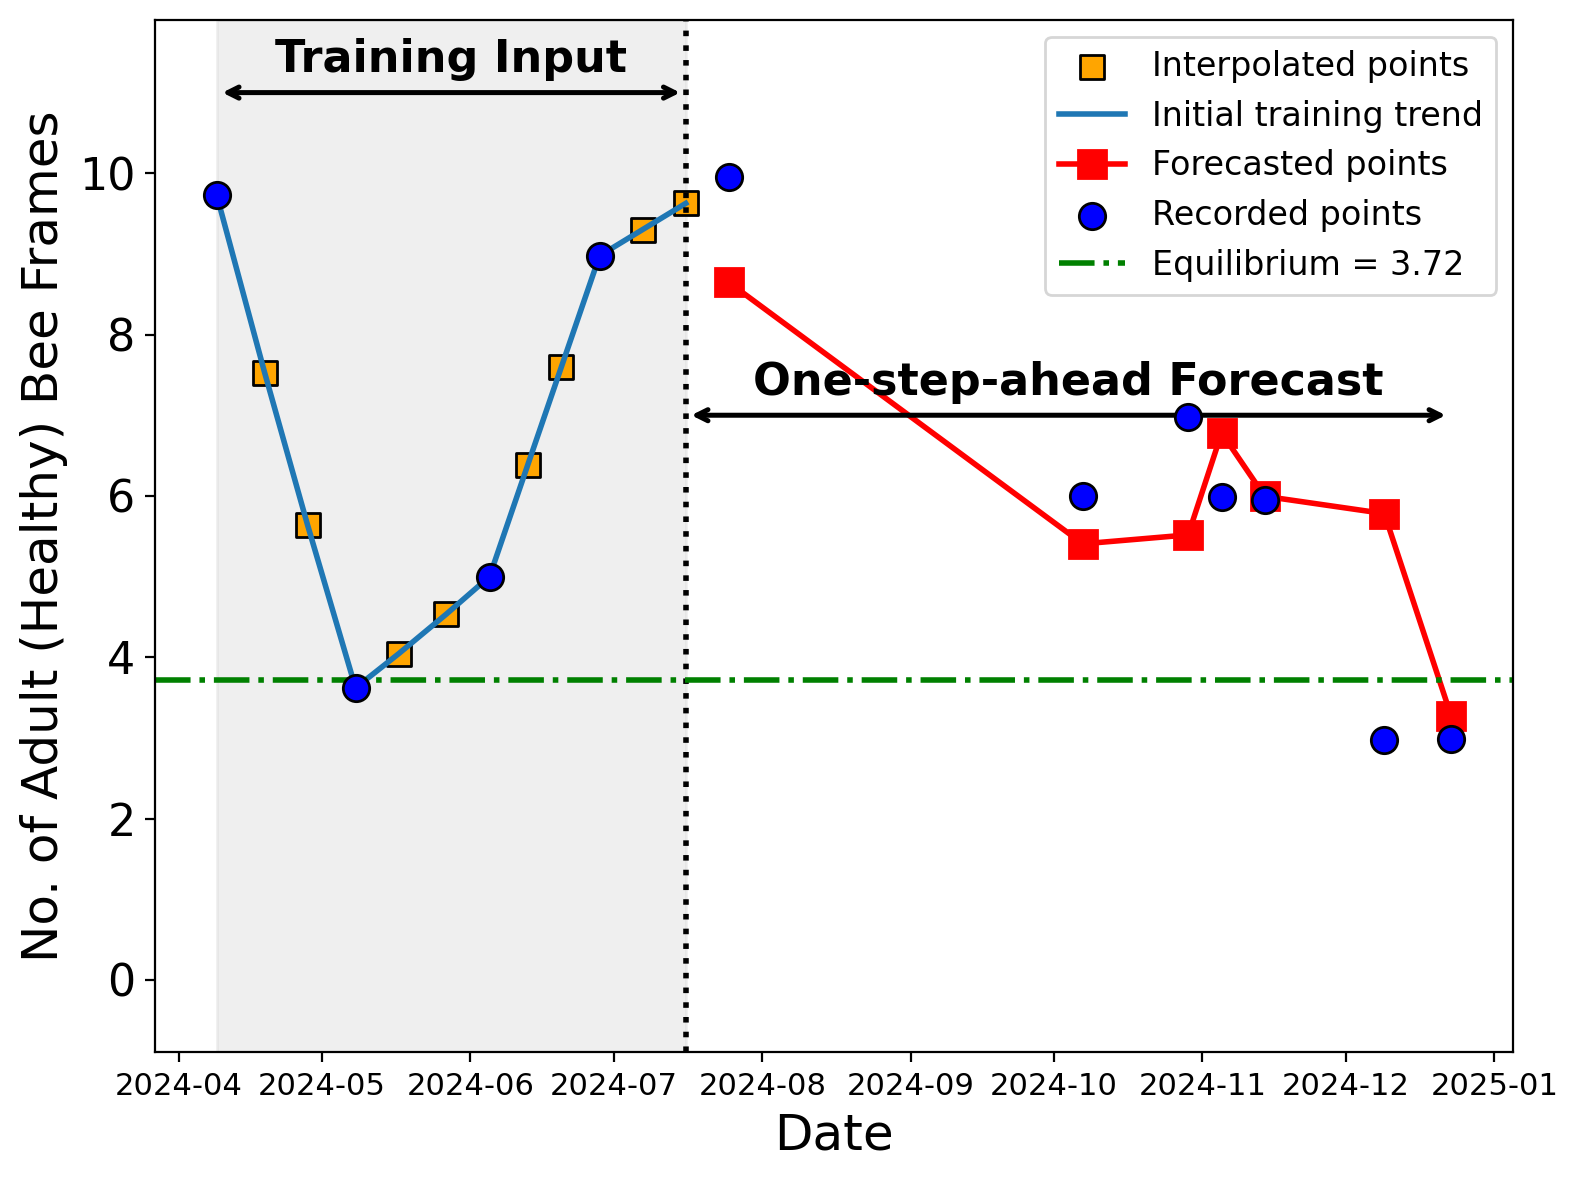

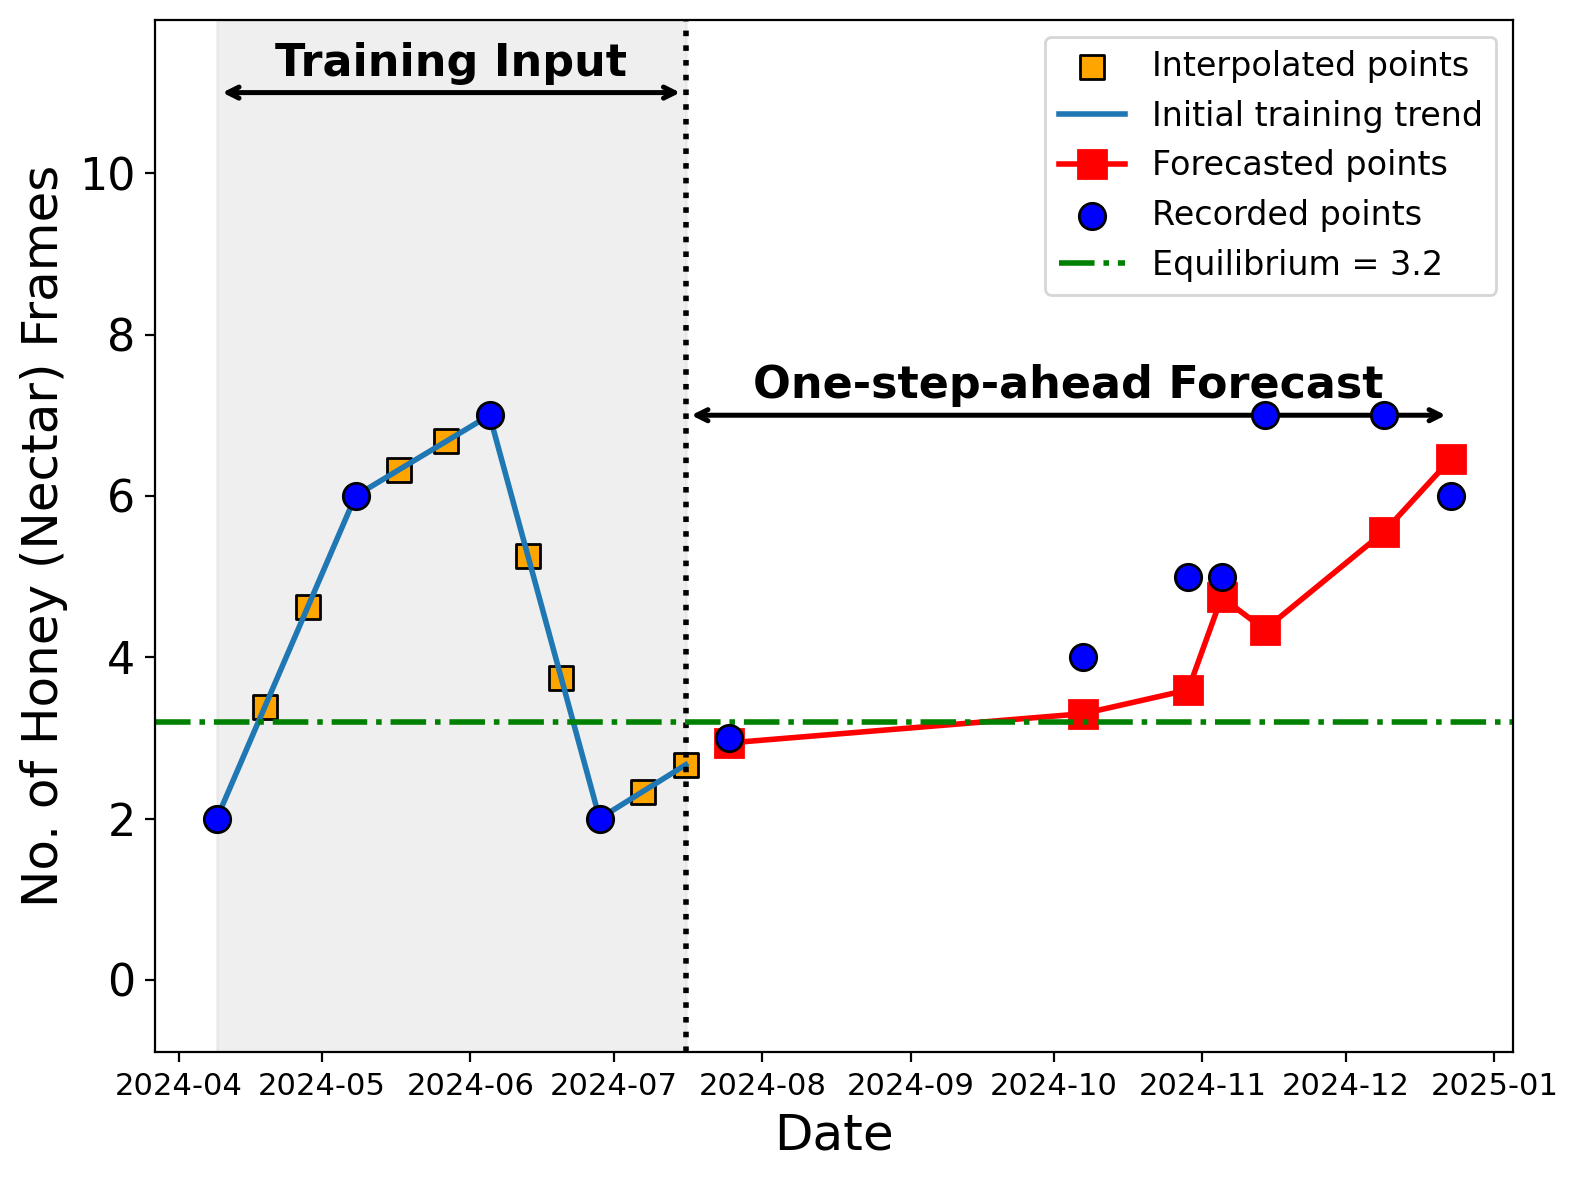

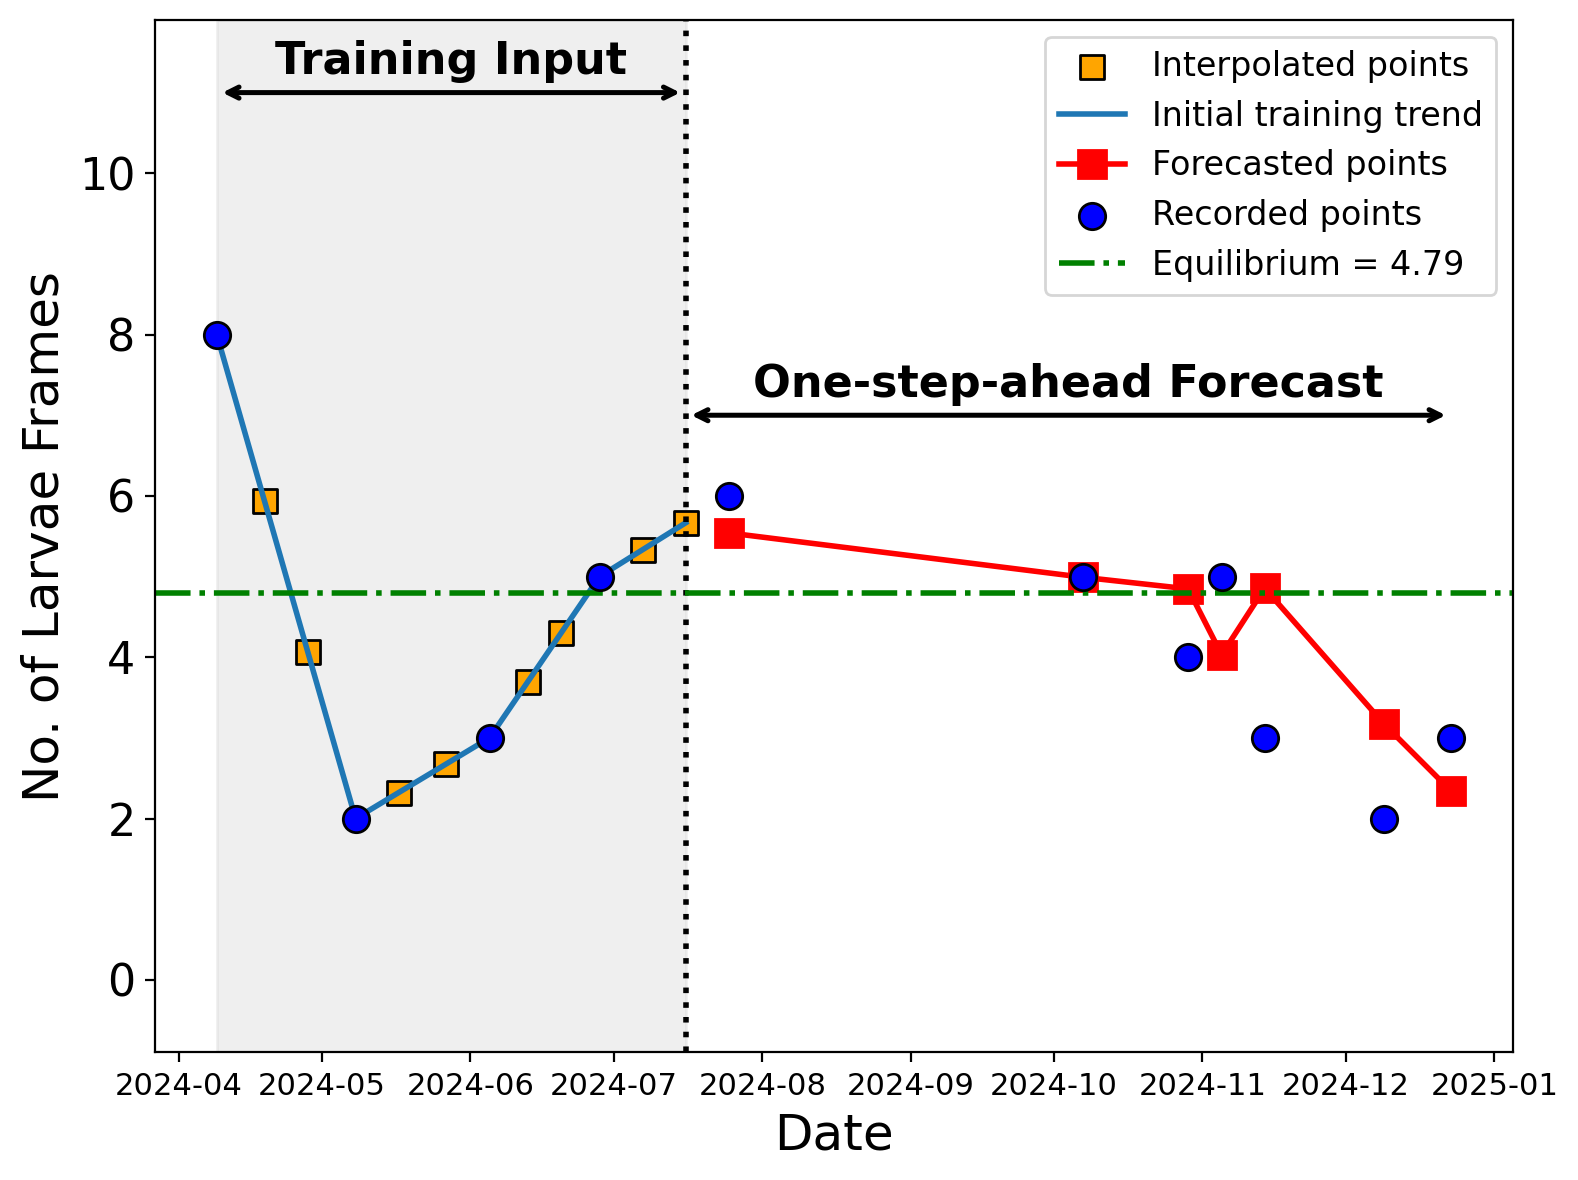

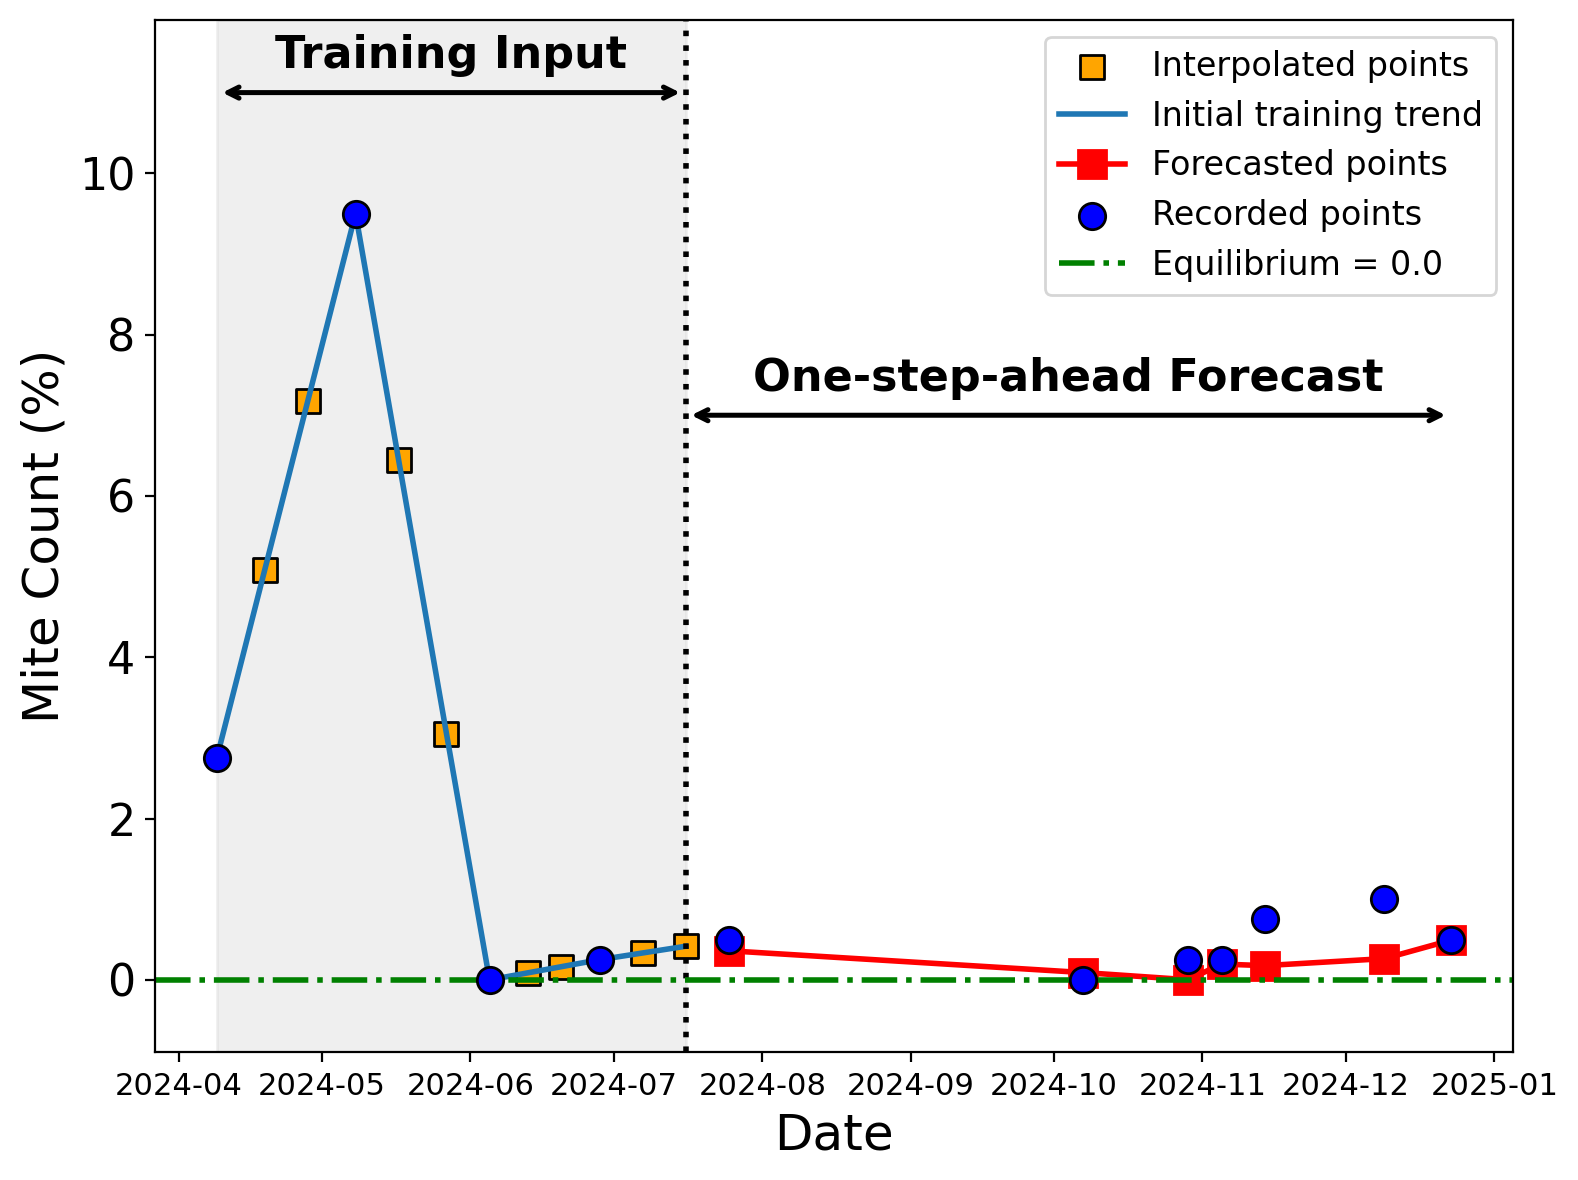

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# =========================
# Load data
# =========================
file_path = r"c:\Bee Temp Data\S-M-14-fig-model-6.csv"   # update path if needed
df = pd.read_csv(file_path)

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# =========================
# Settings
# =========================
training_n = 12

nectar_eq = np.round(3.201272173533209,2)
bee_mite_eq = np.round(2.99861243028284e-08,2)
bee_eq = np.round(3.72250046639967,2)
larvae_eq = np.round(4.787334820762886,2)

original = df[df["Type"] == "Original"]
interp = df[df["Type"] == "Interpolated"]

# =========================
# Helper function
# =========================
def plot_variable_with_forecast(
    df,
    original,
    interp,
    y_col,
    forecast_col,
    eq_value,
    ylabel,
    upper_ylim,
    y1,
    y2,
):
    fig, ax = plt.subplots(figsize=(8, 6), dpi = 200)

    start_date = df["Date"].iloc[0]
    train_end_date = df["Date"].iloc[training_n - 1]
    forecast_end_date = df["Date"].iloc[-1]

    y_min = min(df[y_col].min(), df[forecast_col].min(), eq_value)
    y_max = max(df[y_col].max(), df[forecast_col].max(), eq_value)
    y_range = y_max - y_min if y_max > y_min else 1

    # Give space for arrows/text
    ax.set_ylim(-0.9, upper_ylim)

    arrow_y1 = y1
    arrow_y2 = y2

    # -------------------------
    # Grey background for training input region
    # -------------------------
    ax.axvspan(
        start_date,
        train_end_date,
        color="lightgray",
        alpha=0.35,
        #label="Training input region"
    )

    # -------------------------
    # Plot ALL observed points
    # -------------------------
    

    ax.scatter(
        interp["Date"],
        interp[y_col],
        color='orange',
        label="Interpolated points",
        marker="s",
        edgecolor="black",
        s=80
    )

    # -------------------------
    # Line plot for first 12 training points
    # -------------------------
    train_df = df.iloc[:training_n]

    ax.plot(
        train_df["Date"],
        train_df[y_col],
        linewidth=2,
        label="Initial training trend"
    )

    # -------------------------
    # Forecasted values
    # -------------------------
    forecast_df = df[df[forecast_col].notna()]

    ax.plot(
        forecast_df["Date"],
        forecast_df[forecast_col],
        linewidth=2,
        marker="s",
        markersize=10,
        label="Forecasted points",
        color = 'red'
    )
    
    ax.scatter(
        original["Date"],
        original[y_col],
        color='blue',
        label="Recorded points",
        marker="o",
        edgecolor="black",
        s=90,
        zorder = 5
    )

    # -------------------------
    # Vertical line at 12th point
    # -------------------------
    ax.axvline(
        x=train_end_date,
        linestyle=":",
        linewidth=2,
        color='black'
        #label="End of initial training samples"
    )

    # -------------------------
    # Horizontal equilibrium line
    # -------------------------
    ax.axhline(
        y=eq_value,
        linestyle="-.",
        linewidth=2,
        label=f"Equilibrium = {eq_value}",
        color='green'
    )

    # -------------------------
    # Double arrow: Training Input
    # -------------------------
    ax.annotate(
        "",
        xy=(start_date, arrow_y1),
        xytext=(train_end_date, arrow_y1),
        arrowprops=dict(arrowstyle="<->", linewidth=1.8)
    )

    ax.text(
        start_date + (train_end_date - start_date) / 2,
        arrow_y1 + 0.02 * y_range,
        "Training Input",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    # -------------------------
    # Double arrow: One-step-ahead Forecast
    # -------------------------
    ax.annotate(
        "",
        xy=(train_end_date, arrow_y2),
        xytext=(forecast_end_date, arrow_y2),
        arrowprops=dict(arrowstyle="<->", linewidth=1.8)
    )

    ax.text(
        train_end_date + (forecast_end_date - train_end_date) / 2,
        arrow_y2 + 0.02 * y_range,
        "One-step-ahead Forecast",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold"
    )

    # -------------------------
    # Formatting
    # -------------------------
    ax.set_xlabel("Date", fontsize = 18)
    ax.set_ylabel(ylabel, fontsize = 18)

    #ax.grid(True, alpha=0.3)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=0, fontsize = 11)
    plt.yticks(fontsize = 16)

    ax.legend( fontsize=12)
    plt.tight_layout()

    plt.show()


# =========================
# Plot 1: Healthy bees
# =========================
plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Frame Healthy Bees",
    forecast_col="Bee Forecast",
    eq_value=bee_eq,
    ylabel="No. of Adult (Healthy) Bee Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

# =========================
# Plot 2: Nectar
# =========================
plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Nectar",
    forecast_col="Nectar Forecast",
    eq_value=nectar_eq,
    ylabel="No. of Honey (Nectar) Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Frames Brood",
    forecast_col="Larvae Forecast",
    eq_value=larvae_eq,
    ylabel="No. of Larvae Frames",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

plot_variable_with_forecast(
    df=df,
    original=original,
    interp=interp,
    y_col="Mites Per",
    forecast_col="Mite Forecast Per",
    eq_value=bee_mite_eq,
    ylabel="Mite Count (%)",
    upper_ylim = 11.9,
    y1 = 11,
    y2 = 7,
)

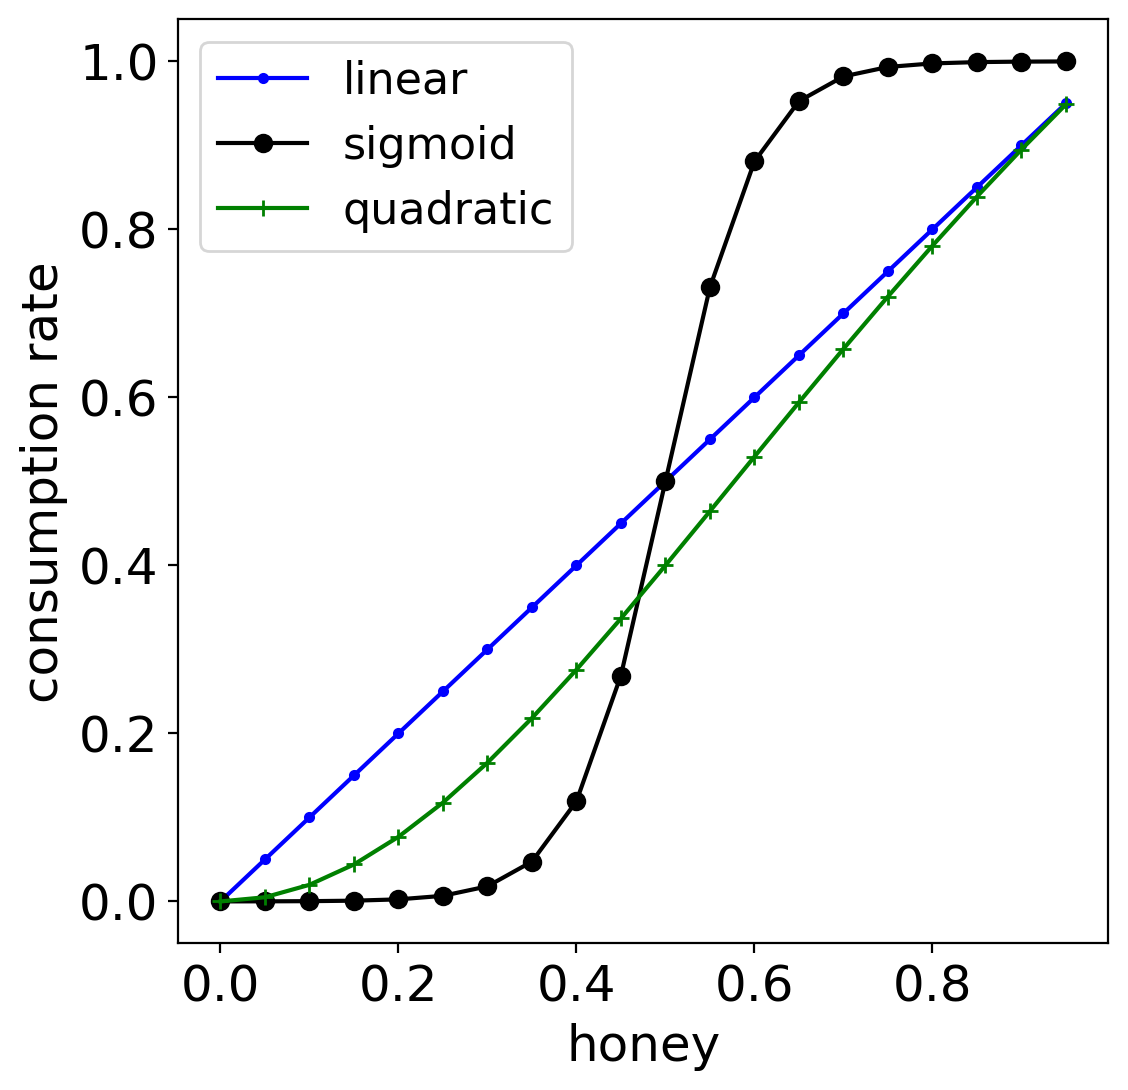

In [46]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
# ]
# ///

import matplotlib.pyplot as plt
import math
import numpy as np
import numpy.typing as npt

def sig(v:float|int) -> float:
    slope:float = 20.0
    exp_val = math.exp( ( v-0.5) * slope )
    result = exp_val / ( 1 + exp_val)
    return result

def michaelis_menten(v: float|int) -> float:
    result = 0.0
    max_value = 1.0
    result = 2* v / ( v + max_value)

def michaelis_menten2(v: float|int) -> float:
    result = 0.0
    max_value = 1.0
    result = 2* v**2 / ( v**2 + max_value**2)
    return result

def main():
    # n:int = 100 # num steps
    n:int = 20 # num steps

    x: npt.NDArray = np.arange(0,1, 1/n)
    y_lin: npt.NDArray = np.copy(x)

    v_sig = np.vectorize(sig)
    y_sigmoid: npt.NDArray = v_sig(x)

    v_mm2 = np.vectorize(michaelis_menten2)
    y_mm2 : npt.NDArray = v_mm2(x)

    fig, ax = plt.subplots(figsize = (6,6), dpi = 200)
    ax.plot(x, y_lin, "b.-", label="linear")
    ax.plot(x, y_sigmoid, "ko-", label="sigmoid")
    ax.plot(x, y_mm2, "g+-", label="quadratic")
    #ax.set_title("Throttling")
    ax.set_xlabel("honey", fontsize = 18)
    ax.set_ylabel("consumption rate", fontsize = 18)
    plt.xticks(fontsize = 18)
    plt.yticks(fontsize = 18)
    plt.legend(fontsize = 16)


if __name__ == "__main__":
    main()

Equilibrium points:
Eq 1: H = 0.000000, B = 0.000000
Eq 2: H = 10.000000, B = 0.000000
Eq 3: H = 7.904600, B = 3.277236


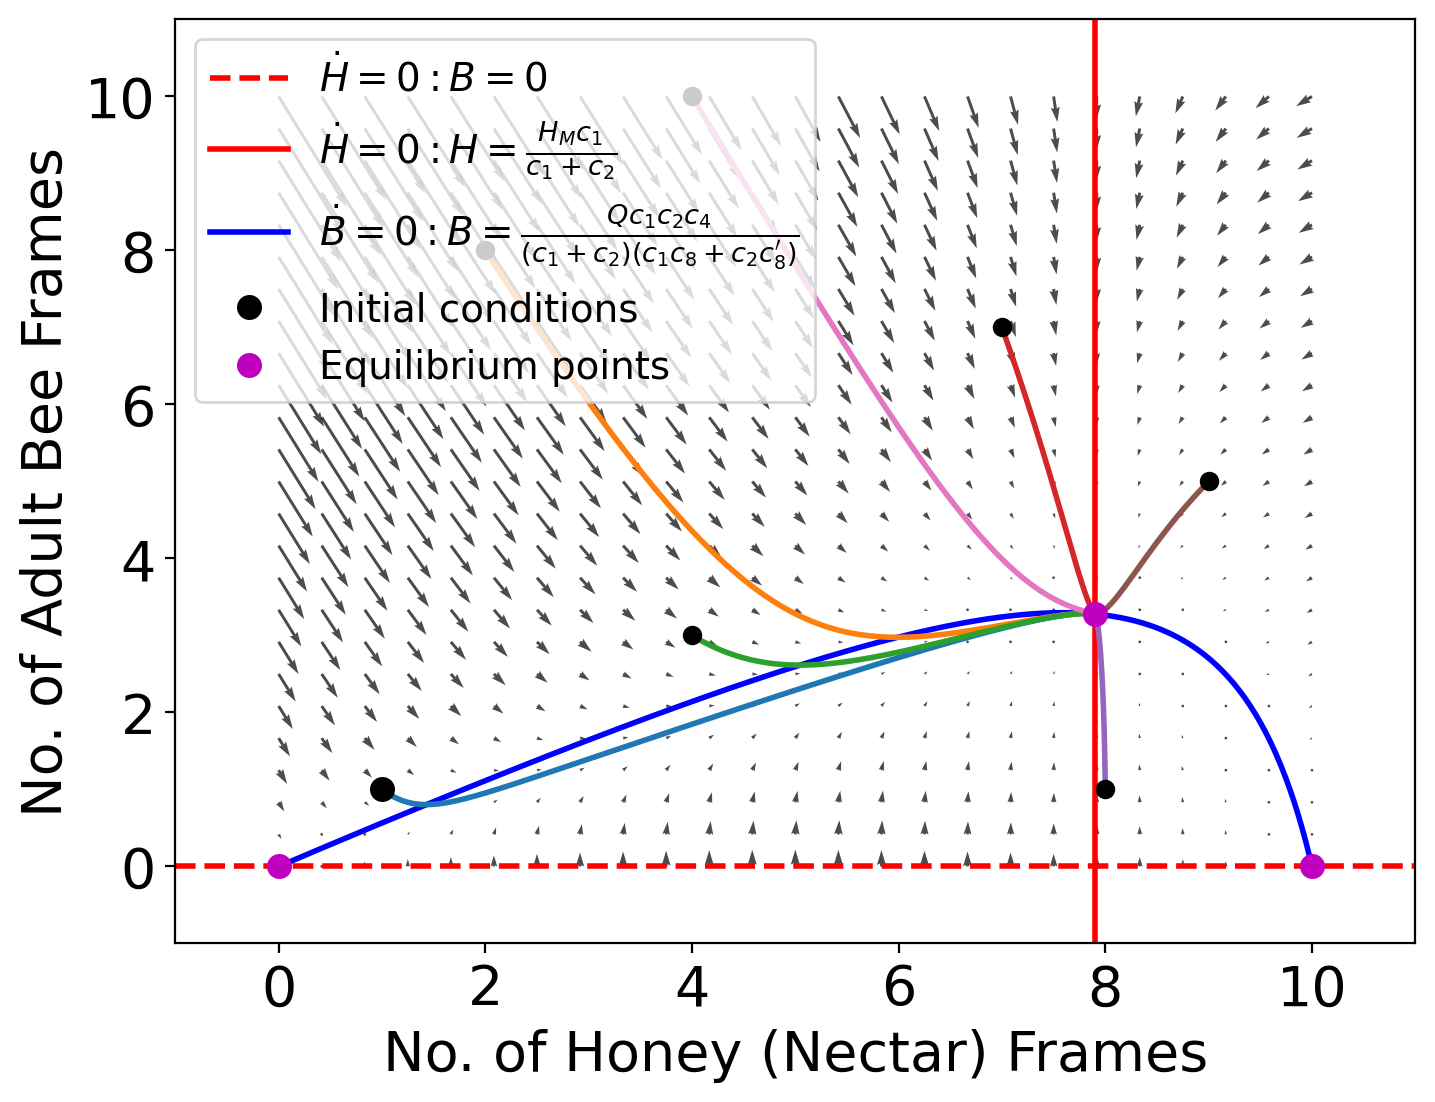

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =========================
# Parameters
# =========================
c2 = 0.01220000
c1 = 0.04602277
c3 = 0.571
c7 = 0.01
c8 = 0.1
Q = 1.0
Hmax = 10.0

# =========================
# System definition
# =========================
def rhs(t, y):
    H, B = y

    dH = B * c1 * (1.0 - H / Hmax) - B * c2 * H / Hmax

    dB = (
        c3 * Q * (1.0 - H / Hmax) * H / Hmax
        - c7 * B * H / Hmax
        - c8 * B * (1.0 - H / Hmax)
    )

    return [dH, dB]

# =========================
# Equilibrium points
# =========================
eq_points = []

eq_points.append((0.0, 0.0))
eq_points.append((Hmax, 0.0))
eq_points.append((
    Hmax * c1 / (c1 + c2),
    Q * c1 * c2 * c3 / ((c1 + c2) * (c1 * c7 + c2 * c8))
))

H_star = Hmax * c1 / (c1 + c2)

print("Equilibrium points:")
for i, (H_eq, B_eq) in enumerate(eq_points, 1):
    print(f"Eq {i}: H = {H_eq:.6f}, B = {B_eq:.6f}")

# =========================
# Grid for vector field
# =========================
H_vals = np.linspace(0, 10, 25)
B_vals = np.linspace(0, 10, 25)
H_grid, B_grid = np.meshgrid(H_vals, B_vals)

dH = B_grid * c1 * (1 - H_grid / Hmax) - B_grid * c2 * H_grid / Hmax

dB = (
    c3 * Q * (1 - H_grid / Hmax) * H_grid / Hmax
    - c7 * B_grid * H_grid / Hmax
    - c8 * B_grid * (1 - H_grid / Hmax)
)

# Normalize arrows
mag = 1

dHn = dH / mag
dBn = dB / mag

# =========================
# Nullclines
# =========================

# dH/dt = 0:
# B = 0 or H = 10*c1/(c1+c2)
H_null_dH = H_star

# dB/dt = 0:
H_curve = np.linspace(0, 10, 400)

den_curve = (
    c7 * (H_curve / Hmax)
    + c8 * (1 - H_curve / Hmax)
)

B_null_dB = np.full_like(H_curve, np.nan)

mask = np.abs(den_curve) > 1e-12

B_null_dB[mask] = (
    c3 * Q
    * (1 - H_curve[mask] / Hmax)
    * (H_curve[mask] / Hmax)
    / den_curve[mask]
)

# =========================
# Plot
# =========================
plt.figure(figsize=(8, 6), dpi=200)

# Vector field
plt.quiver(
    H_grid,
    B_grid,
    dHn,
    dBn,
    angles='xy',
    alpha=0.7
)

# Nullclines
plt.axhline(
    0,
    color='red',
    linestyle='--',
    linewidth=2,
    label=r'$\dot{H}=0: B=0$'
)

plt.axvline(
    H_null_dH,
    color='red',
    linestyle='-',
    linewidth=2,
    label=r'$\dot{{H}}=0: H=\frac{H_Mc_1}{c_1 + c_2}$'
)

plt.plot(
    H_curve,
    B_null_dB,
    color='blue',
    linewidth=2,
    label=r'$\dot{B}=0: B=\frac{Qc_1c_2c_4}{(c_1 + c_2)(c_1c_8 + c_2c_8^{\prime})}$'
)

# =========================
# Example trajectories
# =========================
t_span = (0, 1000)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

initial_conditions = [
    [1, 1],
    [2, 8],
    [4, 3],
    [7, 7],
    [8, 1],
    [9, 5],
    [4, 10]
]

for idx, y0 in enumerate(initial_conditions):

    sol = solve_ivp(
        rhs,
        t_span,
        y0,
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10
    )

    plt.plot(
        sol.y[0],
        sol.y[1],
        linewidth=2
    )

    # Only one legend entry for all initial points
    if idx == 0:
        plt.plot(
            y0[0],
            y0[1],
            'ko',
            markersize=8,
            label='Initial conditions'
        )
    else:
        plt.plot(
            y0[0],
            y0[1],
            'ko',
            markersize=6
        )

# =========================
# Equilibrium points
# =========================
eq_label_added = False

for H_eq, B_eq in eq_points:

    if 0 <= H_eq <= 10 and 0 <= B_eq <= 10:

        if not eq_label_added:
            plt.plot(
                H_eq,
                B_eq,
                'mo',
                markersize=8,
                label='Equilibrium points'
            )
            eq_label_added = True
        else:
            plt.plot(
                H_eq,
                B_eq,
                'mo',
                markersize=8
            )
            
# =========================
# Labels and style
# =========================
plt.xlabel('No. of Honey (Nectar) Frames', fontsize=20)
plt.ylabel('No. of Adult Bee Frames', fontsize=20)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlim(-1, 11)
plt.ylim(-1, 11)

plt.legend(fontsize=14, loc='best')

plt.show()